In [1]:
#import all the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
#load the dataset
data = pd.read_excel("/content/customer-churn-data dictionary.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: '/content/customer-churn-data dictionary.xlsx'

In [ ]:
data

,Column Name,Description of Column,Column Type
0,customerID,Tells the customer ID,object
1,gender,Whether the customer is a male or a female,object
2,SeniorCitizen,Whether the customer is a senior citizen or no...,int64
3,Partner,Whether the customer has a partner or not (Yes...,Object
4,Dependents,Whether the customer has dependents or not (Ye...,object
5,tenure,Number of months the customer has stayed with ...,int64
6,PhoneService,Whether the customer has a phone service or no...,object
7,MultipleLines,Whether the customer has multiple lines or not...,object
8,InternetService,"Customer’s internet service provider (DSL, Fib...",object
9,OnlineSecurity,Whether the customer has online security or no...,object


In [ ]:
df = pd.read_csv("/content/customer.csv")

In [ ]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_binary
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No,0


In [ ]:
df["Churn_binary"] = df["Churn"].map({"Yes": 1, "No": 0})

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Churn_binary'],
      dtype='object')

In [ ]:
df.MonthlyCharges

,MonthlyCharges
0,29.85
1,56.95
2,53.85
3,42.30
4,70.70
...,...
7038,84.80
7039,103.20
7040,29.60
7041,74.40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Tasks to be done:
1.  Data Manipulation:
1a.  Find the total number of male customers
b. Find the total number of customers whose Internet Service is ‘DSL’
c. Extract all the Female senior citizens whose Payment Method is Mailed check & store the
result in ‘new_customer’
d. Extract all those customers whose tenure is less than 10 months or their Total charges is less
than 500$ & store the result in ‘new_customer’

In [ ]:
#This would give you the count of total number of male customers
sum(df['gender']=="Male")

3555

In [ ]:
#This would give you the total number of customers whose Internet Service is ‘DSL’
sum(df['InternetService']=="DSL")

2421

In [ ]:
#With this command, you can extract all the female senior citizens whose payment method
# is ‘Mailed check’
new_customer=df[(df['gender']=='Female') &
(df['SeniorCitizen']==1) & (df['PaymentMethod']=='Mailed check')]
new_customer.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
139,0390-DCFDQ,Female,1,Yes,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,70.45,70.45,Yes
176,2656-FMOKZ,Female,1,No,No,15,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.45,1145.7,Yes
267,3197-ARFOY,Female,1,No,No,19,Yes,No,Fiber optic,Yes,...,No,Yes,Yes,Yes,Month-to-month,Yes,Mailed check,105.00,2007.25,No
451,5760-WRAHC,Female,1,No,No,22,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Month-to-month,Yes,Mailed check,69.75,1545.4,No
470,4933-IKULF,Female,1,No,No,17,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.65,330.6,No


In [ ]:
#With this command, you can extract all those records where either the tenure is less than
# 10 or Total charges is less  than 500.
new_customer=df[(df['tenure']<10) | (df['TotalCharges']<500)]
new_customer.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No


B) Data Visualization:
a. Build a pie-chart to show the distribution of customers would be churning out
b. Build a bar-plot to show the distribution of ‘Internet Service’

In [ ]:
We are starting off by extracting the names of the levels in the churn column, then we
extracting the counts of the levels in the churn column.
Using plt.pie(), we are making the pie-chart. ‘autopct’ parameter is used to add the
percentage distribution in the plot.

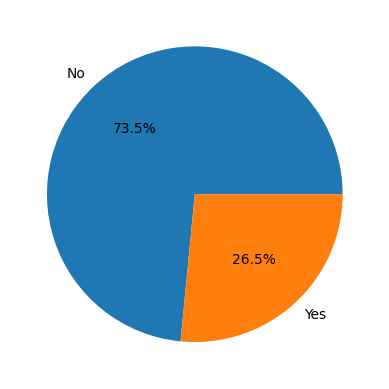

In [ ]:
names = df["Churn"].value_counts().keys().tolist()
sizes=  df["Churn"].value_counts().tolist()
plt.pie(sizes,labels=names,autopct="%0.1f%%")
plt.show()

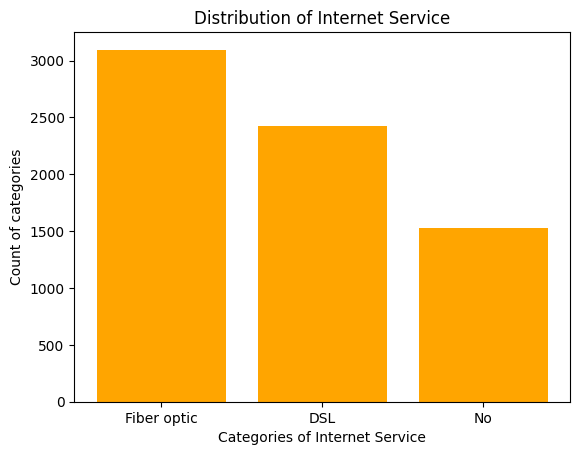

In [ ]:
plt.bar(df['InternetService'].value_counts().keys().tolist(),df['InternetService'].value_counts().tolist(),color='orange')
plt.xlabel('Categories of Internet Service')
plt.ylabel('Count of categories')
plt.title('Distribution of Internet Service')
plt.show()

We are starting off by extracting the target and feature columns.
Going ahead, we are dividing the data into train and test sets using train_test_split().
Here, we are setting the test_size to be 0.30, which means 30% of  the records go into the
test set, while 70% of the records go into the train set.

In [ ]:
x=df[['tenure']]
y=df[['Churn_binary']]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=42)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
model = Sequential()
model.add(Dense(12, input_dim=1, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


After that we create an instance of a sequential model by using Sequential().  
Going ahead we will add the input layer to our model. This input layer would comprise  of
12 nodes and would have ‘relu’ as the activation function. After that we’ll add a hidden
layer with 8 nodes and ‘relu’ as activation function. Finally, we’ll add the output layer which
would comprise of just one node and ‘sigmoid’ as activation function.
We are using ‘sigmoid’ here because this is a binary classification problem and ‘sigmoid’
gives us a probability between 0 & 1.

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

Further, we’ll tune the model. Here, we are using ‘binary_crossentropy’ as our loss function
because this is a binary classification problem.
Optimizer used is ‘adam’ and we would want to calculate the accuracy.

In [ ]:
model.fit(x_train, y_train, epochs=150,validation_data=(x_test,y_test))

Epoch 1/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7529 - loss: 0.5688 - val_accuracy: 0.7553 - val_loss: 0.5136
Epoch 2/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7546 - loss: 0.5148 - val_accuracy: 0.7553 - val_loss: 0.5102
Epoch 3/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7454 - loss: 0.5126 - val_accuracy: 0.7283 - val_loss: 0.5116
Epoch 4/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7426 - loss: 0.5153 - val_accuracy: 0.7283 - val_loss: 0.5101
Epoch 5/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7373 - loss: 0.5124 - val_accuracy: 0.7283 - val_loss: 0.5107
Epoch 6/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7373 - loss: 0.5138 - val_accuracy: 0.7283 - val_loss: 0.5160
Epoch 7/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7373 - loss: 0.5142 - val_accuracy: 0.7283 - val_loss: 0.5107
Epoch 8/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7373 - loss: 0.5126 - val_accu

Going ahead, we will fit the model on the train set and evaluate it on top of the test set. The
number of epochs given over here is 150.

This gives us a final validation accuracy of 75.64%.  But this is not the average accuracy
across 150 epochs, so let’s also find that:

In [ ]:
import numpy as np
np.mean(model.history.history['val_accuracy'])

np.float64(0.741504967212677)

In [ ]:
print(model.history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Churn_binary'],
      dtype='object')

So, the mean accuracy comes out to be 75.62%.

In [ ]:
y_pred=model.predict_classes(x_test)
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

AttributeError: 'Sequential' object has no attribute 'predict_classes'

In [ ]:
y_pred = (model.predict(x_test) > 0.5).astype("int32")
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[1395,  144],
       [ 379,  195]])

Further, we will, predict the values on ‘x_test’ and build a confusion matrix with the actual
values and the predicted values.

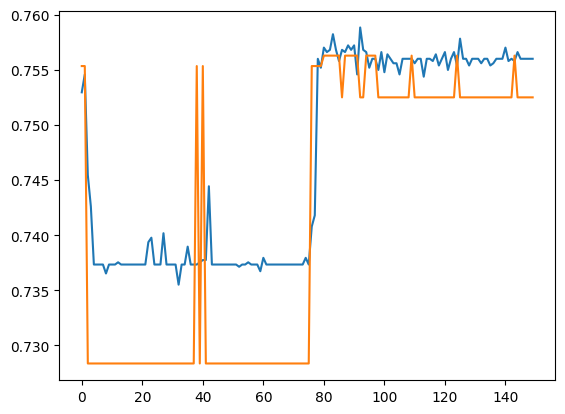

/tmp/ipykernel_13726/2611031505.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


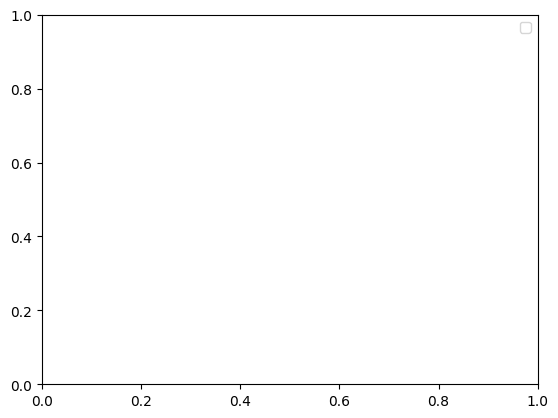

In [ ]:
from matplotlib import pyplot as plt
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.show()
plt.legend()


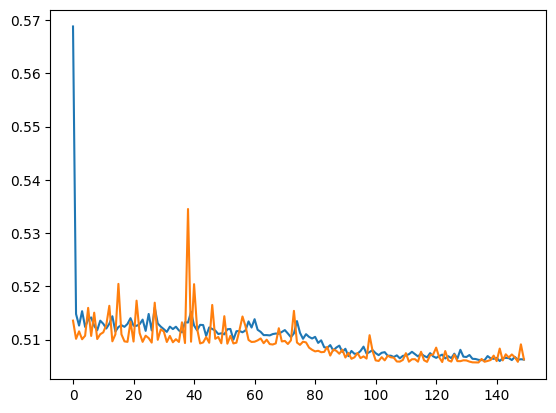

In [ ]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.show()

Finally, we will make the ‘Accuracy vs Epochs’ plot:

Now, we are building our 2nd model, where we are adding a drop-out layer after the input  
layer and the hidden layer.
Drop-out value of 0.3 means that 70% of the nodes in the input layer will be dropped out.
Drop-out value of 0.2 means that 80% of the nodes in the hidden layer will be dropped out.

In [ ]:
model = Sequential()
model.add(Dense(12, input_dim=1, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(8, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

Epoch 1/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7556 - loss: 0.5062 - val_accuracy: 0.7563 - val_loss: 0.5054
Epoch 2/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7562 - loss: 0.5061 - val_accuracy: 0.7525 - val_loss: 0.5054
Epoch 3/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7562 - loss: 0.5058 - val_accuracy: 0.7563 - val_loss: 0.5053
Epoch 4/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7578 - loss: 0.5058 - val_accuracy: 0.7525 - val_loss: 0.5054
Epoch 5/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7570 - loss: 0.5059 - val_accuracy: 0.7525 - val_loss: 0.5057
Epoch 6/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7568 - loss: 0.5059 - val_accuracy: 0.7525 - val_loss: 0.5062
Epoch 7/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7562 - loss: 0.5058 - val_accuracy: 0.7525 - val_loss: 0.5053
Epoch 8/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7560 - loss: 0.5056 - val_accu

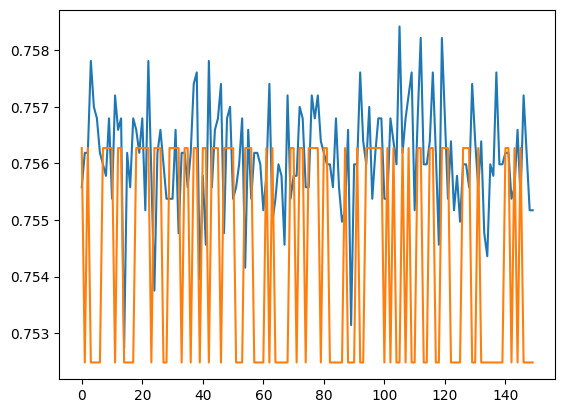

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=150,validation_data=(x_test,y_test))
y_pred = (model.predict(x_test) > 0.5).astype("int32")
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)
from matplotlib import pyplot as plt
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.show()

So, we see that the 2nd model gives us a final validation accuracy of 73.41%. Now, let’s
calculate the mean validation accuracy across 150 epochs:

In [ ]:
import numpy as np
np.mean(model.history.history['val_accuracy'])

np.float64(0.7543776631355286)

So, the mean accuracy comes out to be 73.42%.

By looking at this graph, we can infer that the validation accuracy is constantly 73.41%.
Now, this tells us that something is wrong with our model.  
The most probable explanation for this is the drop-out percentage is very high for the input
layer and the hidden layer and thus the model which we have built might be underfitting
the data.

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Churn_binary'],
      dtype='object')

This time, we are taking ‘Monthly Charges’, ‘Total Charges’ and ‘Tenure’  as  the features
and ‘Churn’ as the target.

In [ ]:
x=df[['MonthlyCharges','tenure','TotalCharges']]#Features
y=df[['Churn_binary']]#Target

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=42)
model = Sequential()
model.add(Dense(12, input_dim=3, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=150,validation_data=(x_test,y_test))
y_pred = (model.predict(x_test) > 0.5).astype("int32")
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

from matplotlib import pyplot as plt
plt.plot(model.history.history['acc'])
plt.plot(model.history.history['val_accuracy'])
plt.show()



Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6860 - loss: nan - val_accuracy: 0.7283 - val_loss: nan
Epoch 2/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7373 - loss: nan - val_accuracy: 0.7283 - val_loss: nan
Epoch 3/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7373 - loss: nan - val_accuracy: 0.7283 - val_loss: nan
Epoch 4/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7373 - loss: nan - val_accuracy: 0.7283 - val_loss: nan
Epoch 5/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7373 - loss: nan - val_accuracy: 0.7283 - val_loss: nan
Epoch 6/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7373 - loss: nan - val_accuracy: 0.7283 - val_loss: nan
Epoch 7/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7373 - loss: nan - val_accuracy: 0.7283 - val_loss: nan
Epoch 8/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7373 - loss: nan - val_accuracy: 0.7283 - val_loss: nan
Epoch 9/150
155/155 ━━━━━━━━

KeyError: 'acc'

After this, we divide the data into train and test sets and build the model on train test and
predict the values on the test set.

So, we see that we get a final validation accuracy of 78.58%.

But, when we look at this graph, we see that there is a constant fluctuation in the validation
accuracy.
So, let’s find out the mean validation accuracy across 150 epochs:

In [ ]:
import numpy as np
np.mean(model.history.history['val_accuracy'])

np.float64(0.7283483147621155)

And this gives a mean validation accuracy of 74.24%

Conclusion:

The first model gave us a mean validation accuracy of 75.62%, the second model had accuracy
of 73.42 and the third model had a mean validation accuracy of 74.24%.
The second model gave us the least accuracy because we added two dropout layers with high
probabilities of dropout.
Now, there could be many factors why third model’s accuracy was less than that of first model.
Most probably one or more of the features used during the model building could be of less
significance leading to the reduction in accuracy.
It should also be kept in mind that these accuracy values are very specific to the
hyperparameters used during the model building process such as optimizers, activation
functions and number of epochs. If we were to tweak these hyperparameters we would get
completely different accuracy values for all the three models.